<a href="https://colab.research.google.com/github/AndresMontesDeOca/GdP/blob/master/Estadistica_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Practico #1
2026-05-23

Nombre: Jose Andres Montes de Oca

Código: a2532

In [57]:
# Librerias


import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro
from IPython.display import display, Math


## Ejericio 1

De 10 monedas hay 3 monedas falsas, que tienen probabilidad 0,6 de mostrar cara al ser lanzadas. Si se toma una moneda al azar, se lanza 14 veces, y en todas ellas se obtiene cara, ¿qué es más probable, que la moneda elegida sea justa o que esté cargada? Dar las probabilidades tanto de que la moneda elegida sea falsa, como de que sea justa.

In [58]:
# Probabilidades iniciales de elegir cada tipo de moneda (probabilidades a priori)
# Hay 3 monedas falsas y 7 justas en un total de 10.
p_falsa = 3 / 10
p_justa = 7 / 10

# Probabilidades de que salga cara en un solo lanzamiento
p_cara_falsa = 0.6
p_cara_justa = 0.5

n = 14

# Como los 14 lanzamientos son independientes, la probabilidad de
# obtener 14 caras seguidas es simplemente el producto de cada uno:
p_14_caras_siendo_falsa = p_cara_falsa ** n
p_14_caras_siendo_justa = p_cara_justa ** n

# Probabilidad total de observar 14 caras (teorema de la prob. total):
# P(A) = P(A|F)*P(F) + P(A|J)*P(J)
p_total_14_caras = (p_14_caras_siendo_falsa * p_falsa) + (p_14_caras_siendo_justa * p_justa)

# Aplicamos el Teorema de Bayes para actualizar las probabilidades (a posteriori)
# P(Falsa | 14 caras) = (P(14 caras | Falsa) * P(Falsa)) / P(14 caras en total)
prob_definitiva_falsa = (p_14_caras_siendo_falsa * p_falsa) / p_total_14_caras
prob_definitiva_justa = (p_14_caras_siendo_justa * p_justa) / p_total_14_caras

print(f"Probabilidad de que sea falsa: {prob_definitiva_falsa:.4f} ({prob_definitiva_falsa * 100:.2f}%)")
print(f"Probabilidad de que sea justa: {prob_definitiva_justa:.4f} ({prob_definitiva_justa * 100:.2f}%)")

Probabilidad de que sea falsa: 0.8462 (84.62%)
Probabilidad de que sea justa: 0.1538 (15.38%)


## Ejericio 2

Sean $X$ e $Y$ dos v.a. continuas con densidad conjunta:

$$
f_{X,Y}(x,y) = \begin{cases} Ky & 81x^2 \leq y \leq 7x \\ 0 & \text{en otro caso} \end{cases}
$$

**Encontrar:**

*a)* Determine el valor de $K$  
*b)* Encuentre la densidad marginal $f_X(x)$ de $X$  
*c)* Encuentre la densidad marginal $f_Y(y)$ de $Y$  
*d)* Encuentre la densidad condicional $f_{X|Y}(x|y)$ de $X$ dado $Y$  
*e)* Encuentre la densidad condicional $f_{Y|X}(y|x)$ de $Y$ dado $X$

In [59]:
# Variables
x, y, K = sp.symbols('x y K', real=True)

f_xy = K * y

y_lower_bound = 81 * x**2
y_upper_bound = 7 * x

# a) Valor de K (integrando e igualando a 1)
int_y = sp.integrate(f_xy, (y, y_lower_bound, y_upper_bound))
int_total = sp.integrate(int_y, (x, 0, sp.Rational(7, 81)))
valor_K = sp.solve(int_total - 1, K)[0]
f = f_xy.subs(K, valor_K)

# b) Marginal de X
f_X = sp.integrate(f, (y, y_lower_bound, y_upper_bound))

# c) Marginal de Y
f_Y = sp.integrate(f, (x, y/7, sp.sqrt(y)/9))

# d) Condicional X dado Y
f_X_Y = sp.simplify(f / f_Y)

# e) Condicional Y dado X
f_Y_X = sp.simplify(f / f_X)

print(f"a) K = {valor_K}")
print(f"b) f_X(x) = {f_X}")
print(f"c) f_Y(y) = {f_Y}")
print(f"d) f_X|Y(x|y) = {f_X_Y}")
print(f"e) f_Y|X(y|x) = {f_Y_X}")

a) K = 7971615/16807
b) f_X(x) = -52301766015*x**4/33614 + 7971615*x**2/686
c) f_Y(y) = 885735*y**(3/2)/16807 - 7971615*y**2/117649
d) f_X|Y(x|y) = 63*y/(7*y**(3/2) - 9*y**2)
e) f_Y|X(y|x) = -2*y/(x**2*(6561*x**2 - 49))


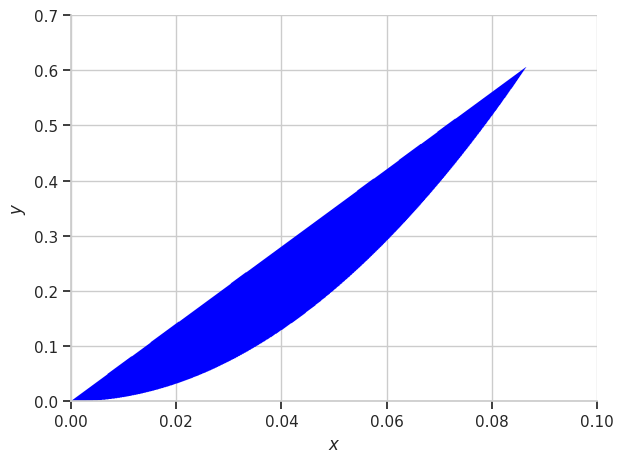

In [60]:
# Sombreado donde se cumplen ambas condiciones a la vez
sp.plot_implicit(sp.And(y >= y_lower_bound, y <= y_upper_bound), (x, 0, 0.1), (y, 0, 0.7))
plt.show()

## Ejercicio 3

Sea:

$$
Y = R \cos(2\pi \cdot \Phi),
$$

donde $R$ y $\Phi$ son variables aleatorias independientes. La fase $\Phi$ se distribuye uniforme sobre el intervalo $(0,1)$, mientras que la amplitud $R$ tiene una distribución de Rayleigh con densidad $f(r) = r e^{-r^2/2}$ para $r > 0$. Muestre que $Y$ tiene una distribución normal.

*Pista: Defina $Y = R \text{sen}(2\pi \cdot \Phi)$ y $X = R \cos(2\pi \cdot \Phi)$ y utilice la relación $X^2 + Y^2 = R^2$ para calcular la densidad conjunta de $(X,Y)$ a partir de la densidad conjunta de $(R, \Phi)$.*

In [61]:
x, y, r, phi = sp.symbols('x y r phi', real=True)

# Densidad conjunta f(r, phi) (son independientes)
f_r_phi = r * sp.exp(-r**2 / 2)

# Jacobiano
J = 1 / (2 * sp.pi * r)

# Densidad conjunta f(x, y)
f_xy_con_r = f_r_phi * J
f_xy = f_xy_con_r.subs(r, sp.sqrt(x**2 + y**2))

# Marginal f(y)
f_y = sp.integrate(f_xy, (x, -sp.oo, sp.oo))

# Aprovechamos GdP y usamos LaTex
display(Math(rf"f_{{X,Y}}(x, y) = {sp.latex(f_xy)}"))
display(Math(rf"f_Y(y) = {sp.latex(f_y)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

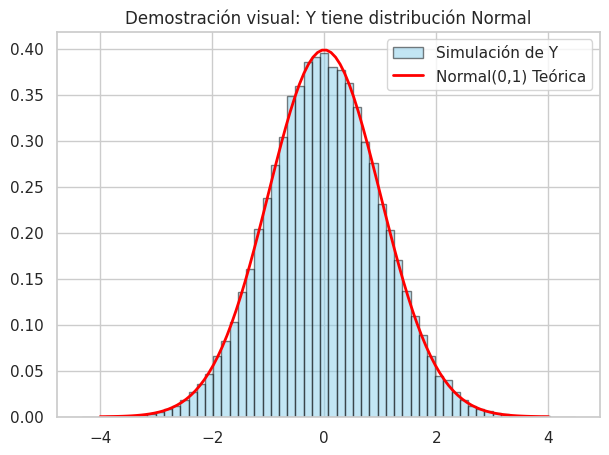

In [62]:
N = 100000

# Generamos Phi (Uniforme) y R (Rayleigh)
phi_sim = np.random.uniform(0, 1, N)
r_sim = np.random.rayleigh(1, N)

# Calculamos Y
y_sim = r_sim * np.cos(2 * np.pi * phi_sim)

plt.figure(figsize=(7, 5))
plt.hist(y_sim, bins=60, density=True, alpha=0.5, color='skyblue', edgecolor='black', label='Simulación de Y')

# Superponemos la curva Normal(0,1) teórica para comprobar
y_vals = np.linspace(-4, 4, 100)
f_y_teorica = (1 / np.sqrt(2 * np.pi)) * np.exp(-y_vals**2 / 2)
plt.plot(y_vals, f_y_teorica, color='red', linewidth=2, label='Normal(0,1) Teórica')

plt.title('Demostración visual: Y tiene distribución Normal')
plt.legend()
plt.show()

In [63]:
# Tambien lo comprobamos estadisticamente, con un test de Shapito-Wilk
stat, p_value = shapiro(y_sim)

print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

Shapiro-Wilk Test Statistic: 1.0000
P-value: 0.5206


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 100000.
  res = hypotest_fun_out(*samples, **kwds)


## Ejercicio 4

In [64]:
# DataFrame de fechas de 2023 a 2025
fechas = pd.date_range(start='2023-01-01', end='2025-12-31')
df = pd.DataFrame({'Fecha': fechas})

# Extraemos componentes de la fecha para mapear los efectos
df['Anio'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Dia_Semana'] = df['Fecha'].dt.dayofweek # Pandas: 0=Lunes, 6=Domingo

# Diccionarios de efectos
efecto_anio = {2023: 10, 2024: 15, 2025: 20}
efecto_mes = {1: 10, 2: 15, 3: 20, 4: 20, 5: 25, 6: 25,
              7: 30, 8: 25, 9: 25, 10: 20, 11: 15, 12: 10}
efecto_dia = {0: 20, 1: 30, 2: 35, 3: 30, 4: 20, 5: 10, 6: 10}

# Calculo de Lambda base
lambda_base = df['Anio'].map(efecto_anio) + df['Mes'].map(efecto_mes) + df['Dia_Semana'].map(efecto_dia)

In [65]:
# a) Creamos las simulaciones

# Poisson para Francisco (Efecto local +20)
np.random.seed(1515) # Para reproducibilidad
df['Clientes_Francisco'] = np.random.poisson(lambda_base + 20)

# Poisson para Miguel (Efecto local +10)
df['Clientes_Miguel'] = np.random.poisson(lambda_base + 10)

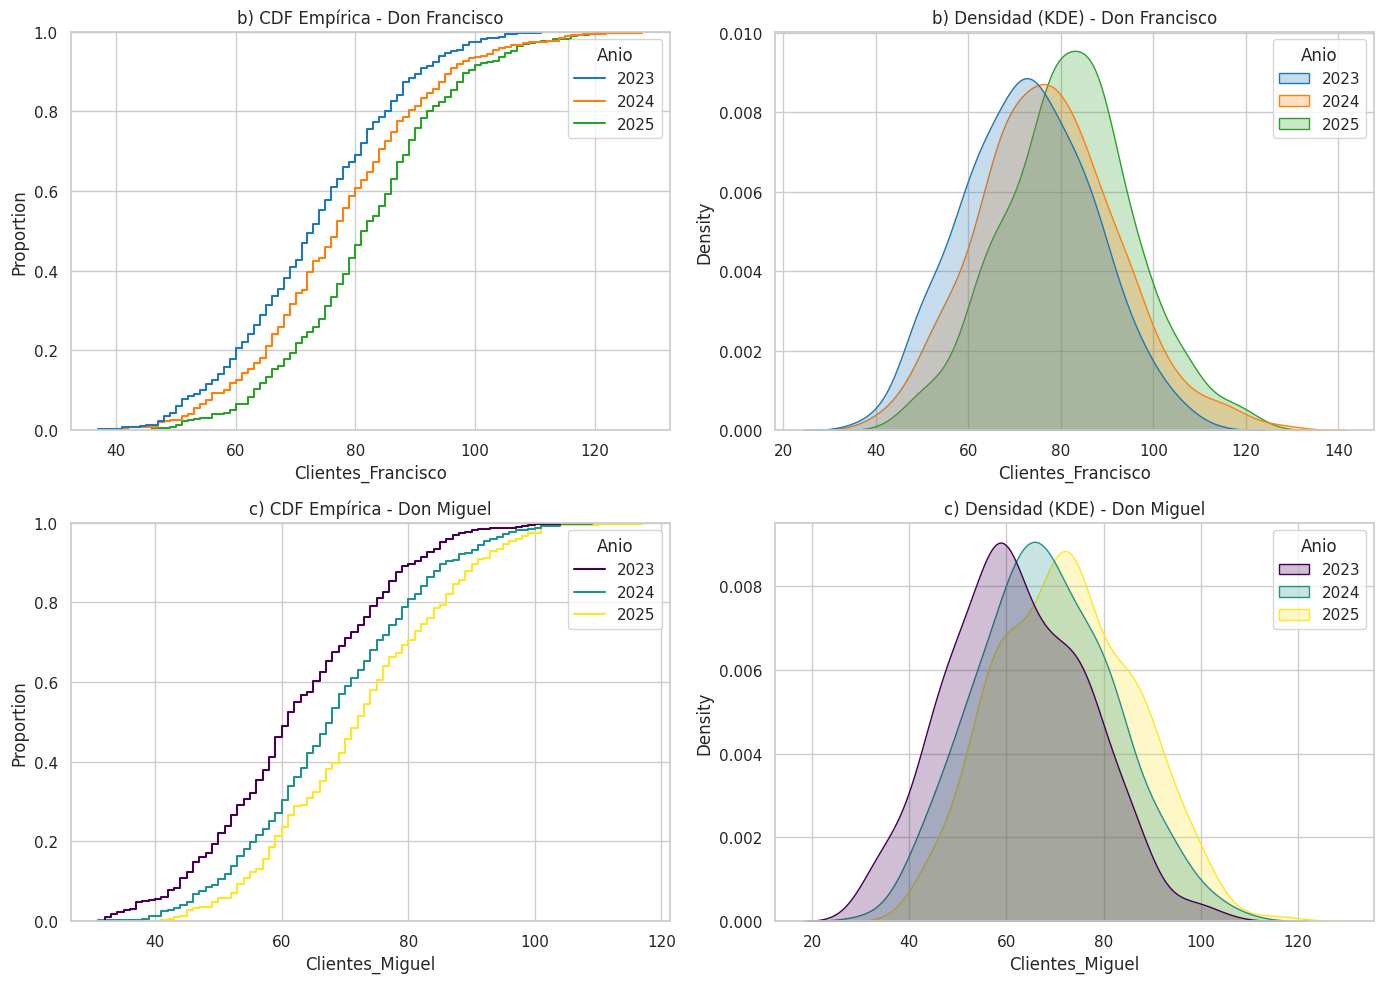

In [66]:

# b) y c) DISTRIBUCIÓN EMPÍRICA Y DENSIDAD POR Anio

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# Francisco - Función Empírica de Distribución (ECDF)
sns.ecdfplot(data=df, x='Clientes_Francisco', hue='Anio', palette='tab10', ax=axes[0, 0])
axes[0, 0].set_title('b) CDF Empírica - Don Francisco')

# Francisco - Aproximación de Densidad (KDE)
sns.kdeplot(data=df, x='Clientes_Francisco', hue='Anio', fill=True, palette='tab10', ax=axes[0, 1])
axes[0, 1].set_title('b) Densidad (KDE) - Don Francisco')

# Miguel - Función Empírica de Distribución (ECDF)
sns.ecdfplot(data=df, x='Clientes_Miguel', hue='Anio', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('c) CDF Empírica - Don Miguel')

# Miguel - Aproximación de Densidad (KDE)
sns.kdeplot(data=df, x='Clientes_Miguel', hue='Anio', fill=True, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('c) Densidad (KDE) - Don Miguel')

plt.tight_layout()
plt.show()


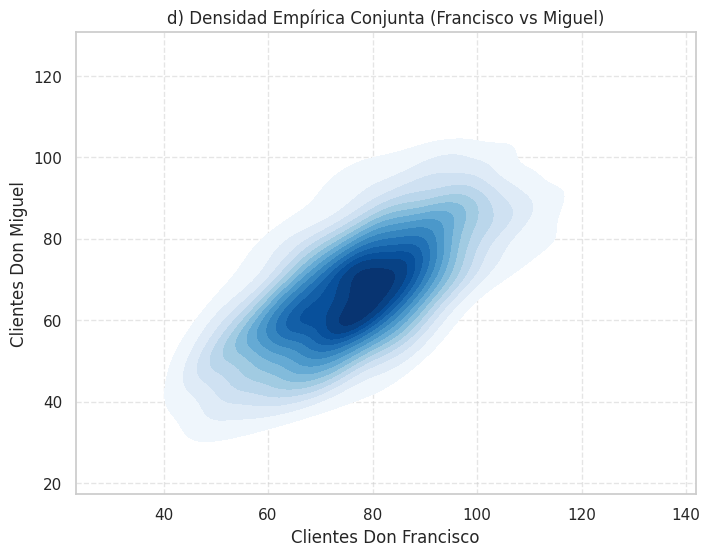

In [67]:
# d) DENSIDAD EMPÍRICA CONJUNTA

plt.figure(figsize=(8, 6))

# Usamos un mapa de calor/contorno (KDE 2D) para la densidad conjunta f(x,y)
sns.kdeplot(x=df['Clientes_Francisco'], y=df['Clientes_Miguel'], cmap="Blues", fill=True, levels=15)

plt.title('d) Densidad Empírica Conjunta (Francisco vs Miguel)')
plt.xlabel('Clientes Don Francisco')
plt.ylabel('Clientes Don Miguel')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()